<img align="left" src="https://scienceserver.linea.org.br/images/linea-logo.png" width=120 style="padding: 20px"> <br>
<img align="left" src="https://jupyter.org/assets/homepage/hublogo.svg" width=200 style="padding: 20px"> <br>
<br><br><br><br>

# Acesso ao Catálogo DES DR2 via TAP/pyvo

---

Bem vindo(a) ao LIneA JupyterHub!

Autora original: Julia Gschwend

Autores secundários: Marcela Vitti e Heleno Campos

Ultima atualização: Heleno Campos 27/05/2026

O LIneA JupyterHub oferece acesso a dados públicos disponíveis online e a dados privados de levantamentos fotométricos cuja participação de cientistas brasileiros com _data rights_ é apoiada pelo LIneA. Neste notebook vamos exemplificar o acesso aos dados públicos do levantamento _Dark Energy Survey_ (DES) utilizando a biblioteca [`pyvo`](https://pyvo.readthedocs.io/) via protocolo TAP (_Table Access Protocol_).

Caso precise de ajuda, entre em contato: [helpdesk@linea.org.br](mailto:helpdesk@linea.org.br)

## 1. Sobre os dados

<img align="left" src="https://www.darkenergysurvey.org/wp-content/uploads/2016/01/des-logo-rev-lg.png" width=350 style="background-color:black; padding: 20px; margin-right: 2em">

O [Dark Energy Survey (DES)](https://www.darkenergysurvey.org/) é um levantamento fotométrico em 5 bandas do ótico ao infravermelho (_grizY_) que tem como principal objetivo a determinação da equação de estado da energia escura. O DES observou ~700 milhões de objetos em ~5000 graus quadrados no hemisfério sul durante 6 anos.

<img align="center" src="https://www.darkenergysurvey.org/wp-content/uploads/2021/06/dr2_footprint.png" width=500 style="padding: 20px"> <br>
_Figura: Footprint do DES Data Release 2_

O [segundo data release (DR2)](https://des.ncsa.illinois.edu/releases/dr2), com os dados dos seis anos de observação, está disponível publicamente e pode ser acessado pelo [LIneA User Query](https://userquery.linea.org.br/query) ou diretamente via TAP, como veremos a seguir.

## 2. Instalação das dependências

Execute a célula abaixo caso as bibliotecas não estejam instaladas no seu ambiente. No LIneA JupyterHub, `pyvo`, `requests` e `astropy` já estão disponíveis.

In [1]:
# Descomente se precisar instalar
# !pip install pyvo requests astropy pandas matplotlib

## 3. Conexão com o banco de dados

### 3.1 Importações

In [2]:
import os
import time
from io import BytesIO

import pyvo
import requests
import pandas as pd
import matplotlib.pyplot as plt
from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy.table import Table

### 3.2 Criando a conexão TAP

In [3]:
TAP_URL = "https://userquery.linea.org.br/tap"

session = requests.Session()

tap = pyvo.dal.TAPService(TAP_URL, session=session)
print(f"Conectado ao serviço TAP: {TAP_URL}")

Conectado ao serviço TAP: https://userquery.linea.org.br/tap


## 4. Explorando o catálogo

### 4.1 Primeira consulta

Vamos verificar a conexão recuperando os primeiros objetos da tabela:

In [4]:
query_teste = """
    SELECT TOP 10
        coadd_object_id, ra, dec, mag_auto_g, mag_auto_r, mag_auto_i
    FROM des_dr2.main
"""

resultado = tap.run_sync(query_teste).to_table().to_pandas()
resultado

,coadd_object_id,ra,dec,mag_auto_g,mag_auto_r,mag_auto_i
0,1270163061,35.445821,-24.607306,23.939405,23.678900,23.013727
1,1270162916,35.438756,-24.605615,24.022610,23.855818,23.905073
2,1270162812,35.441462,-24.604495,24.851677,24.500599,24.575817
3,1270162769,35.440616,-24.603977,25.656025,25.438318,24.784079
4,1270162742,35.439156,-24.603648,25.941912,24.406208,24.096910
5,1270162678,35.440207,-24.602968,25.179398,25.071276,25.472876
6,1270162694,35.446517,-24.603154,26.345615,25.479507,25.897068
7,1270162524,35.444560,-24.601513,24.628918,24.672293,23.700449
8,1270162978,35.414528,-24.606149,25.345709,25.263897,24.966808
9,1270160506,35.469308,-24.580664,22.088829,20.573952,19.119516


## 5. Tipos de consulta

### 5.1 Consultas síncronas

Recomendadas para consultas **rápidas** (retornam em segundos) ou com poucos resultados. O notebook aguarda a resposta antes de continuar.

```python
resultado = tap.run_sync(query)
df = resultado.to_table().to_pandas()
```

**Limitação:** o servidor TAP impõe um timeout (~30 segundos). Para queries maiores, use consultas assíncronas.

### 5.2 Consultas assíncronas

Para queries que retornam **muitos registros** ou que demoram mais de 30 segundos, use o modo assíncrono: o job é enviado ao servidor, executado em segundo plano, e o resultado é buscado ao final.

Filas disponíveis (`QUEUE`):
- `"default"` — até 30 segundos
- `"five_minutes"` — até 5 minutos
- `"two_hours"` — até 2 horas (para queries grandes)

O exemplo abaixo usa `TOP 100` para demonstrar o fluxo sem demorar. Para queries reais, remova o `TOP 100` e ajuste a fila conforme necessário.


In [5]:
query_async = """
    SELECT TOP 100
        ra, dec, mag_auto_g, mag_auto_r, mag_auto_i
    FROM des_dr2.main
    WHERE mag_auto_g < 20
"""

# Submeter o job
job = tap.submit_job(query_async, QUEUE="five_minutes")
job.run()
print(f"Job enviado. ID: {job.job_id}")

# Aguardar a conclusão
while job.phase not in ("COMPLETED", "ERROR", "ABORTED"):
    print(f"Status: {job.phase}   ", end="\r")
    time.sleep(5)

print(f"Status final: {job.phase}")

# Buscar o resultado
if job.phase == "COMPLETED":
    result_url = f"{TAP_URL}/async/{job.job_id}/results/result"
    r = requests.get(result_url, headers=session.headers)
    df_async = Table.read(BytesIO(r.content), format="votable").to_pandas()
    print(f"{len(df_async):,} objetos retornados")
    display(df_async.head())
else:
    print(f"Erro na execução do job: {job.phase}")

Job enviado. ID: 499f63f2-5a67-4a79-a20a-abc537956446
Status final: COMPLETED
100 objetos retornados


,ra,dec,mag_auto_g,mag_auto_r,mag_auto_i
0,337.317558,-43.495772,7.295285,7.986818,9.165403
1,1.583809,-49.075433,7.338358,7.696028,10.262071
2,86.114408,-22.450146,7.349017,7.638395,8.647511
3,349.266968,-58.234275,7.441561,7.964750,15.403710
4,70.985522,-18.666912,7.587840,7.979962,15.362645


## 6. Busca espacial com Q3C

O DES DR2 possui ~700 milhões de objetos. Uma busca por faixas de coordenadas (`WHERE ra BETWEEN x AND y`) faria uma varredura em toda a tabela, o que pode levar muitos minutos.

Para tirar proveito da indexação espacial do banco, usamos as funções da biblioteca [Q3C](https://github.com/segasai/q3c):

| Função | Uso |
|---|---|
| `CONTAINS(POINT(), CIRCLE())` | Cone search em torno de um ponto |
| `CONTAINS(POINT(), POLYGON())` | Região poligonal arbitrária |

### 6.1 Colunas utilizadas nas consultas

| Coluna | Descrição |
|---|---|
| `coadd_object_id` | Identificador único do objeto |
| `ra`, `dec` | Coordenadas equatoriais (graus) |
| `extended_class_coadd` | Classificação morfológica: 0–1 = estrelas, 2–3 = galáxias, -9 = sem dado |
| `flags_{g,r,i,z,y}` | Flags de qualidade — use `< 4` para fotometria confiável |
| `mag_auto_{g,r,i,z,y}_dered` | Magnitudes corrigidas pela extinção galáctica (recomendado) |
| `magerr_auto_{g,r,i}` | Erros nas magnitudes |

### 6.2 Alvo: Galáxia Anã de Sculptor

Vamos buscar estrelas na região da [Galáxia Anã de Sculptor](https://en.wikipedia.org/wiki/Sculptor_Dwarf_Galaxy), uma galáxia satélite da Via Láctea visível no hemisfério sul.

| Coordenada | Valor |
|---|---|
| Ascensão Reta | 01h 00m 09.3s |
| Declinação | −33° 42' 33" |

Usamos a classe `SkyCoord` do Astropy para converter as coordenadas para graus:

In [6]:
sculptor = SkyCoord('01h00m09.3s', '-33d42m33s', frame='icrs')

ra0  = sculptor.ra.deg
dec0 = sculptor.dec.deg

print(f"RA:  {ra0:.4f} graus")
print(f"Dec: {dec0:.4f} graus")

RA:  15.0387 graus
Dec: -33.7092 graus


### 6.3 Exemplo 1 — região retangular (`q3c_poly_query`)

Selecionamos uma região de 1° × 1° em torno de Sculptor (margem de 0.5° em cada direção).

Vértices (RA, Dec): (14.5, −34.2), (15.5, −34.2), (15.5, −33.2), (14.5, −33.2).

In [7]:
query_1 = """
    SELECT coadd_object_id, ra, dec, flags_g,
           mag_auto_g_dered, mag_auto_r_dered, mag_auto_i_dered,
           magerr_auto_g, magerr_auto_r, magerr_auto_i
    FROM des_dr2.main
    WHERE CONTAINS(
              POINT('ICRS', ra, dec),
              POLYGON('ICRS', 14.5, -34.2, 15.5, -34.2, 15.5, -33.2, 14.5, -33.2)
          ) = 1
      AND extended_class_coadd < 2
"""

In [8]:
%%time
dados_exemplo_1 = tap.run_sync(query_1).to_table().to_pandas()
print(f"{len(dados_exemplo_1):,} estrelas retornadas")
dados_exemplo_1.head()

92,171 estrelas retornadas
CPU times: total: 5.34 s
Wall time: 11.2 s


,coadd_object_id,ra,dec,flags_g,mag_auto_g_dered,mag_auto_r_dered,mag_auto_i_dered,magerr_auto_g,magerr_auto_r,magerr_auto_i
0,1128471419,15.273652,-34.195642,0,24.415539,23.575392,23.199387,0.159203,0.095005,0.115842
1,1128471460,15.180068,-34.195975,0,25.341976,23.550106,22.373770,0.328399,0.088893,0.050377
2,1128471551,15.215235,-34.196883,0,24.997734,25.052414,25.041574,0.202615,0.270988,0.440482
3,1128471421,15.192331,-34.195670,0,26.327871,25.314045,25.691408,0.498941,0.254170,0.655048
4,1128471312,15.197925,-34.194846,0,26.669353,24.292896,23.388275,1.253565,0.199896,0.144264


### 6.4 Exemplo 2 — região circular (`q3c_radial_query`)

Selecionamos um cone de raio 0.5° em torno das coordenadas de Sculptor. Esta é a seleção que usaremos para o diagrama cor-magnitude.

In [9]:
query_2 = f"""
    SELECT coadd_object_id, ra, dec, flags_g,
           mag_auto_g_dered, mag_auto_r_dered, mag_auto_i_dered,
           magerr_auto_g, magerr_auto_r, magerr_auto_i
    FROM des_dr2.main
    WHERE CONTAINS(
              POINT('ICRS', ra, dec),
              CIRCLE('ICRS', {ra0}, {dec0}, 0.5)
          ) = 1
      AND extended_class_coadd < 2
"""

In [10]:
%%time
dados_exemplo_2 = tap.run_sync(query_2).to_table().to_pandas()
print(f"{len(dados_exemplo_2):,} estrelas retornadas")
dados_exemplo_2.head()

92,325 estrelas retornadas
CPU times: total: 5.3 s
Wall time: 16.3 s


,coadd_object_id,ra,dec,flags_g,mag_auto_g_dered,mag_auto_r_dered,mag_auto_i_dered,magerr_auto_g,magerr_auto_r,magerr_auto_i
0,1122727306,14.557781,-33.946765,0,24.082115,23.847797,23.505333,0.082960,0.086747,0.107491
1,1122726787,14.555605,-33.944384,0,19.320562,18.623671,18.374662,0.002212,0.001443,0.001766
2,1122728900,14.570334,-33.960214,0,24.935427,24.340649,24.197414,0.159988,0.119837,0.178981
3,1122726545,14.566678,-33.941236,0,21.085602,20.284254,19.991343,0.008367,0.005221,0.006591
4,1122726650,14.568469,-33.941044,0,23.966036,23.825239,23.734270,0.106215,0.121164,0.189120


In [11]:
# Exportar os dados para uso posterior
dados_exemplo_2.to_csv('dados_sculptor_DES.csv', index=False)
print("Arquivo salvo: dados_sculptor_DES.csv")

Arquivo salvo: dados_sculptor_DES.csv


## 7. Visualizações

### 7.1 Distribuição espacial

Comparando a distribuição dos objetos nos dois exemplos:

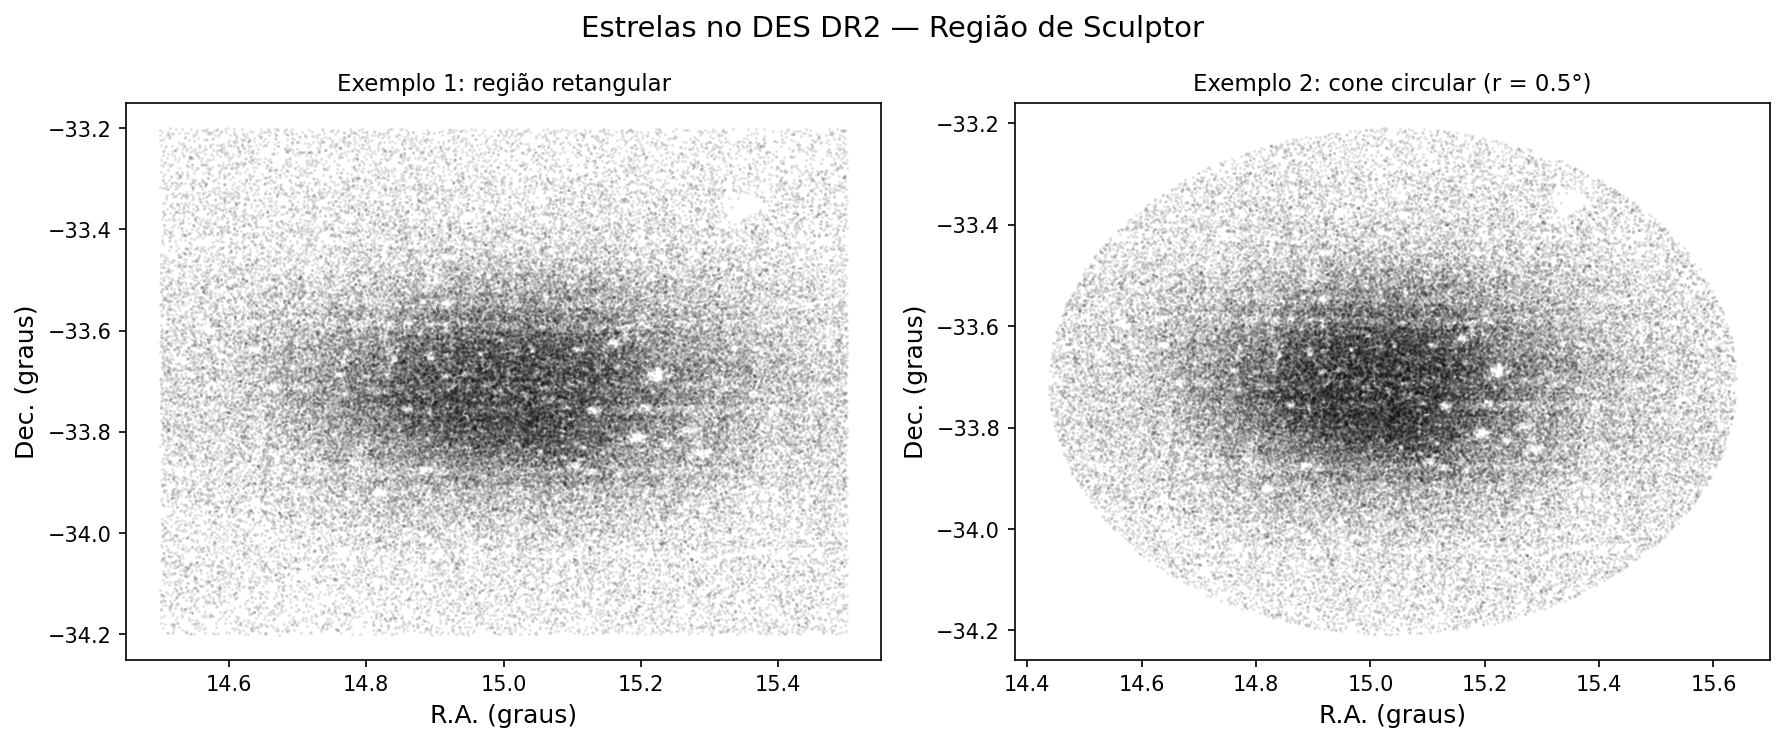

CPU times: total: 625 ms
Wall time: 619 ms


In [12]:
%%time
fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=150)
fig.suptitle("Estrelas no DES DR2 — Região de Sculptor", fontsize=14)

for ax, dados_plot, titulo in zip(
    axes,
    [dados_exemplo_1, dados_exemplo_2],
    ["Exemplo 1: região retangular", "Exemplo 2: cone circular (r = 0.5°)"]
):
    ax.plot(dados_plot.ra, dados_plot.dec, 'k.', alpha=0.1, markersize=1)
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel("R.A. (graus)", fontsize=12)
    ax.set_ylabel("Dec. (graus)", fontsize=12)

plt.tight_layout()
plt.show()

### 7.2 Mapa de densidade

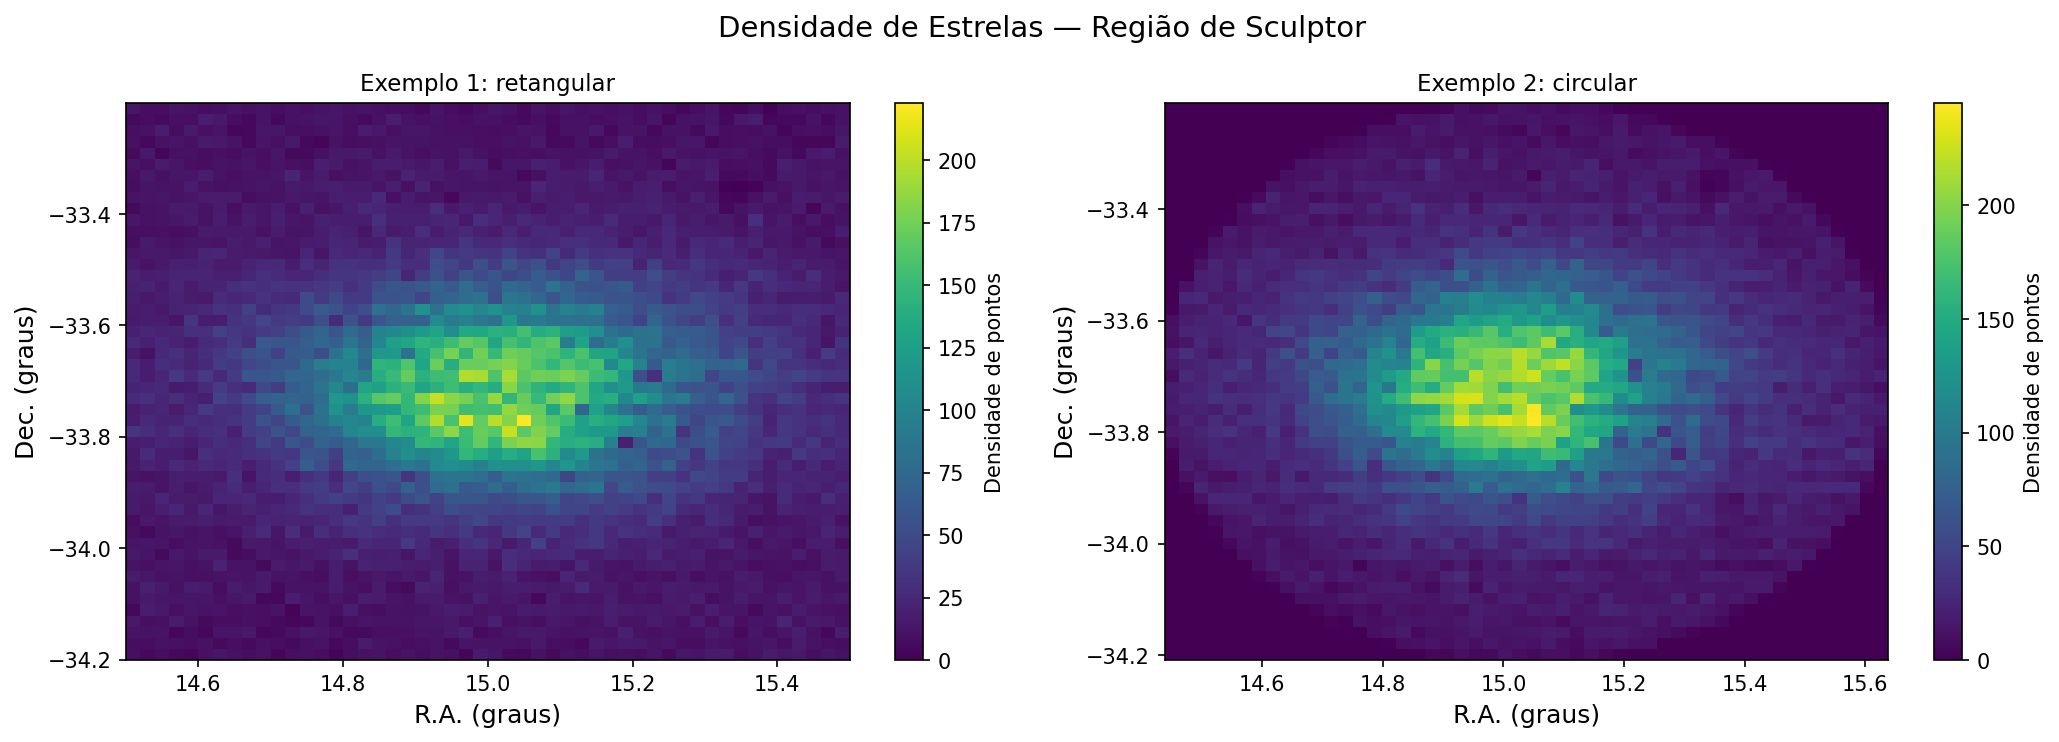

CPU times: total: 578 ms
Wall time: 605 ms


In [13]:
%%time
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)
fig.suptitle("Densidade de Estrelas — Região de Sculptor", fontsize=14)

for ax, dados_plot, titulo in zip(
    axes,
    [dados_exemplo_1, dados_exemplo_2],
    ["Exemplo 1: retangular", "Exemplo 2: circular"]
):
    h = ax.hist2d(dados_plot.ra, dados_plot.dec, bins=50, cmap='viridis')
    plt.colorbar(h[3], ax=ax, label="Densidade de pontos")
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel("R.A. (graus)", fontsize=12)
    ax.set_ylabel("Dec. (graus)", fontsize=12)

plt.tight_layout()
plt.show()

## 8. Limpeza e preparação dos dados

Para o CMD usaremos apenas o Exemplo 2 (cone circular). Primeiro liberamos da memória o dataframe que não precisamos mais:

In [14]:
dados = dados_exemplo_2.copy()
del dados_exemplo_1
del dados_exemplo_2

Renomeamos as colunas para nomes mais curtos:

In [15]:
dados.rename(columns={
    "coadd_object_id": "object_id",
    "mag_auto_g_dered": "mag_g",
    "mag_auto_r_dered": "mag_r",
    "mag_auto_i_dered": "mag_i",
    "magerr_auto_g":    "err_g",
    "magerr_auto_r":    "err_r",
    "magerr_auto_i":    "err_i",
}, inplace=True)

dados.info()

<class 'pandas.DataFrame'>
RangeIndex: 92325 entries, 0 to 92324
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   object_id  92325 non-null  int64  
 1   ra         92325 non-null  float64
 2   dec        92325 non-null  float64
 3   flags_g    92325 non-null  int32  
 4   mag_g      92325 non-null  float64
 5   mag_r      92325 non-null  float64
 6   mag_i      92325 non-null  float64
 7   err_g      92325 non-null  float64
 8   err_r      92325 non-null  float64
 9   err_i      92325 non-null  float64
dtypes: float64(8), int32(1), int64(1)
memory usage: 6.7 MB


Calculamos a **cor g−r** (diferença de magnitudes entre duas bandas). Quanto menor o valor, mais azul a estrela; quanto maior, mais vermelha:

In [16]:
dados["gmr"] = dados.mag_g - dados.mag_r
dados[["mag_g", "mag_r", "gmr"]].describe()

,mag_g,mag_r,gmr
count,92325.000000,92325.000000,92325.000000
mean,24.840327,23.808789,1.031538
std,7.968373,3.976295,7.475527
min,14.976521,14.984582,-74.026001
25%,23.285387,22.983185,0.179291
50%,24.314089,24.014946,0.340961
75%,25.171951,24.776678,0.523010
max,99.000000,99.000000,78.951706


Filtramos a amostra para manter apenas estrelas com **fotometria confiável**:

- `flags_g < 4` — qualidade da extração fotométrica na banda _g_
- `mag != 99` — magnitudes com valor 99 indicam medição malsucedida

Aplicamos o mesmo critério para as bandas _r_ e _i_:

In [17]:
dados.query(
    "flags_g < 4 & mag_g != 99. & mag_r != 99. & mag_i != 99.",
    inplace=True
)

print(f"{len(dados):,} estrelas após limpeza")
dados.describe()

91,011 estrelas após limpeza


,object_id,ra,dec,flags_g,mag_g,mag_r,mag_i,err_g,err_r,err_i,gmr
count,9.101100e+04,91011.000000,91011.000000,91011.000000,91011.000000,91011.000000,91011.000000,91011.000000,91011.000000,91011.000000,91011.000000
mean,1.129383e+09,15.027164,-33.713503,1.005626,24.015362,23.611259,23.573854,0.935655,0.144750,0.281471,0.404102
std,3.312454e+06,0.235310,0.169164,1.350893,1.709405,1.682072,1.772944,199.529052,0.628716,4.090654,0.463073
min,1.121172e+09,14.437847,-34.208583,0.000000,15.297066,14.984582,15.734713,0.000259,0.000243,0.000288,-5.007725
25%,1.128465e+09,14.870582,-33.817420,0.000000,23.265169,22.964490,22.914465,0.051052,0.050796,0.084343,0.178912
50%,1.131093e+09,15.023740,-33.715265,0.000000,24.288784,23.993677,24.005873,0.105125,0.105509,0.182697,0.338406
75%,1.131138e+09,15.176973,-33.610717,3.000000,25.139183,24.749152,24.747708,0.193826,0.178061,0.306050,0.516586
max,1.132575e+09,15.638803,-33.209614,3.000000,38.823757,31.349447,33.540947,60121.039062,120.758568,1098.342163,12.784710


## 9. Diagrama Cor-Magnitude (CMD)

O diagrama cor-magnitude é uma das ferramentas mais clássicas da astronomia. Cada estrela é plotada pela sua **cor** (eixo X, g−r) e seu **brilho** (eixo Y, magnitude _r_ — eixo invertido: menor = mais brilhante). Estrelas de mesma temperatura e idade ocupam posições semelhantes no diagrama, formando a chamada **sequência principal**.

Usamos `hexbin` com escala logarítmica de cor para visualizar a densidade de estrelas em cada região do diagrama:

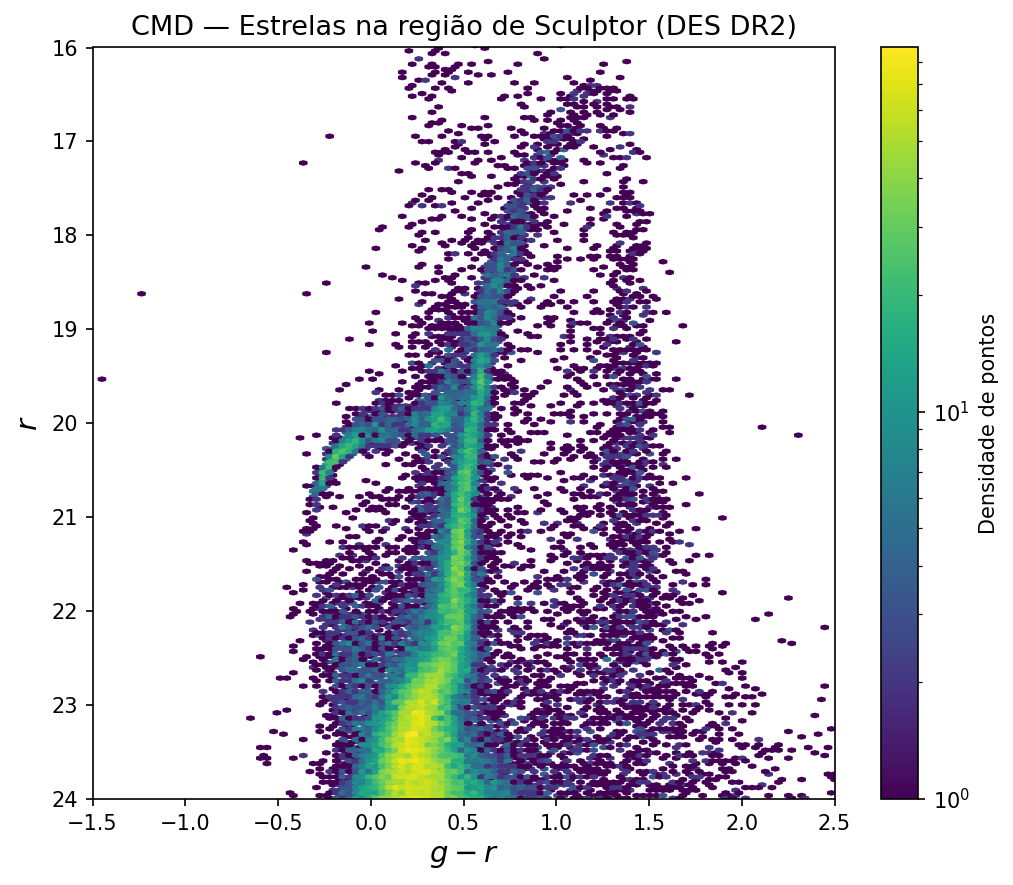

91,011 estrelas plotadas


In [18]:
fig, ax = plt.subplots(figsize=(7, 6), dpi=150)

hb = ax.hexbin(
    dados.gmr, dados.mag_r,
    gridsize=500,
    bins='log',         # escala logarítmica de densidade
    cmap='viridis'
)

plt.colorbar(hb, ax=ax, label="Densidade de pontos")

ax.set_xlabel(r"$g - r$", fontsize=14)
ax.set_ylabel(r"$r$", fontsize=14)
ax.set_title("CMD — Estrelas na região de Sculptor (DES DR2)", fontsize=13)
ax.set_xlim(-1.5, 2.5)
ax.set_ylim(24, 16)    # eixo invertido: mais brilhante no topo

plt.tight_layout()
plt.savefig('cmd_sculptor_DES.png', dpi=150)
plt.show()
print(f"{len(dados):,} estrelas plotadas")

A sequência diagonal bem definida é a **sequência principal estelar** — estrelas de diferentes temperaturas (azuis à esquerda, vermelhas à direita) e luminosidades (brilhantes no topo, fracas na base). A estrutura compacta e nítida é característica de estrelas, que são objetos pontuais com fotometria precisa. Populações estelares distintas da Galáxia Anã de Sculptor podem aparecer como sobreposições à sequência principal da Via Láctea.

---

_Este notebook é baseado no repositório_ [jupyterhub-tutorial](https://github.com/linea-it/jupyterhub-tutorial)